In [23]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.readinput import load_data_alps, prepare_sample

import xgboost as xgb
from sklearn.model_selection import train_test_split
import sklearn.metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

import tl2cgen
import treelite.frontend

First we download the data using the helper function

In [ ]:
df = load_data_alps()
df.describe()

,fa,cqL33,cuR,cdR,clL33,ceR,chi2
count,2.698000e+04,26980.000000,26980.000000,26980.000000,26980.000000,26980.000000,26980.000000
mean,5.845577e+07,-0.009286,0.016015,-0.009959,0.002508,-0.013455,46.264334
std,2.580756e+07,1.498414,1.729906,1.737496,1.723179,1.484068,29.675148
min,1.000197e+07,-2.999926,-2.999474,-2.999903,-2.999895,-2.999763,12.629824
25%,3.670949e+07,-1.061595,-1.484606,-1.525241,-1.482380,-1.080382,18.443011
50%,6.001425e+07,-0.004769,0.032349,-0.010650,-0.001157,-0.018770,21.344440
75%,8.109356e+07,1.054247,1.508295,1.494395,1.493351,1.063763,80.000000
max,9.999405e+07,2.999991,2.999752,2.999980,2.999928,2.999918,80.000000


We define a cut-off for the points whose likelihood we're going to model, or to discard (try different values)

In [9]:
cutoff = 10.0

In [10]:
X = df[["fa", 'cqL33', 'cuR', 'cdR', 'clL33', 'ceR']]
y = df['chi2']
y_classifier = (y < np.min(y) + cutoff).astype(int)

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X, y_classifier, test_size=0.2)

model_clf = xgb.XGBClassifier(
    tree_method = 'hist', # Faster tree construction algorithm
    max_depth = 6, # Maximum depth of the tree
    n_estimators = 5000, # Number of trees to train
    learning_rate = 0.1, # Step size shrinkage
    gamma = 0, # Minimum loss reduction required to make a further partition
    min_child_weight = 1, # Minimum sum of instance weight needed in a child
    subsample = 0.8, # Fraction of samples to use for each tree
    colsample_bytree = 0.8, # Fraction of features to use for each tree
    eval_metric = 'logloss', # Evaluation metric
    early_stopping_rounds = 5,
    scale_pos_weight = len(y_classifier)/np.sum(y_classifier)-1, # Handle class imbalance
    nthread = -1, # Use all available CPU cores
)

model_clf.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False
              )

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",5
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [41]:
len(y_classifier)/np.sum(y_classifier)-1

np.float64(0.9764119844700021)

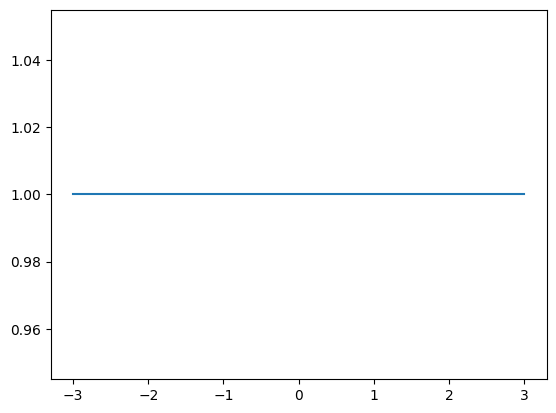

In [19]:
plt.plot(np.linspace(-3, 3, 100), [model_clf.predict(np.array([[x, 0.1, 0.1, 0.1, 0.1, 0.1]])) for x in np.linspace(1e7, 1e8, 100)])

In [48]:
def optuna_obj(trial):
    param = {
        'objective': 'binary:logistic',
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': 200,
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 2.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
    }
    model = xgb.XGBClassifier(**param, tree_method='hist', eval_metric='logloss', early_stopping_rounds=10, nthread=-1)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    predictions = model.predict(X_val)
    accuracy = sklearn.metrics.accuracy_score(y_val, predictions)
    return accuracy

In [49]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(optuna_obj, n_trials=400, timeout=3600, n_jobs=-1, show_progress_bar=True)

  0%|          | 0/400 [00:00<?, ?it/s]

In [50]:
study.best_params

{'max_depth': 7,
 'learning_rate': 0.2614467421469737,
 'gamma': 0.4469101120824744,
 'min_child_weight': 6,
 'subsample': 0.6855645410448674,
 'colsample_bytree': 0.9797637409623611,
 'scale_pos_weight': 0.9722982183939975,
 'reg_alpha': 0.9478644283637159,
 'reg_lambda': 0.2553728987884266}

In [67]:
model = xgb.XGBClassifier(**study.best_params, tree_method='hist', eval_metric=['error', 'logloss'], early_stopping_rounds=5, nthread=-1, n_estimators=200)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9797637409623611
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",5
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

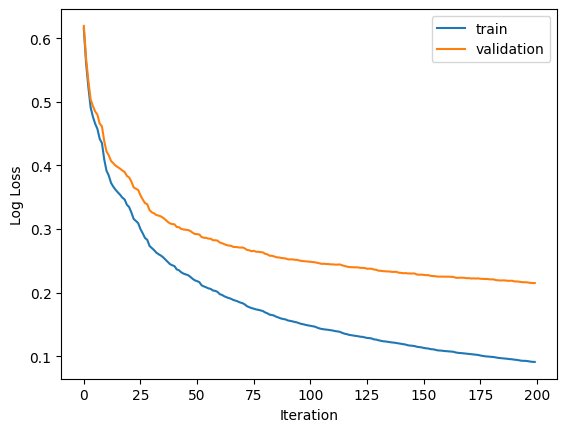

In [52]:
plt.plot(model.evals_result()['validation_0']['logloss'], label='train')
plt.plot(model.evals_result()['validation_1']['logloss'], label='validation')
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.legend()

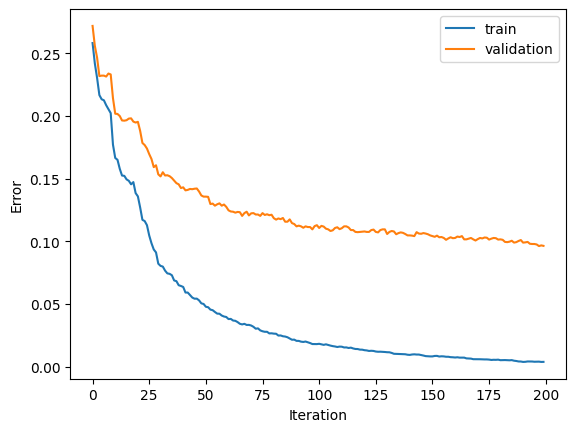

In [53]:
plt.plot(model.evals_result()['validation_0']['error'], label='train')
plt.plot(model.evals_result()['validation_1']['error'], label='validation')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.legend()

In [54]:
model.save_model('xgb_classifier.ubj')

In [55]:
tree_clf = treelite.frontend.from_xgboost(model.get_booster())
tl2cgen.export_lib(tree_clf, toolchain='gcc', libpath='xgb_classifier.so', params={'parallel_comp': 4})

[19:49:30] /tmp/tmpfk5q71dd/libbuild/_deps/treelite-src/src/serializer.cc:202: The model you are loading originated from a newer Treelite version; some functionalities may be unavailable.
Currently running Treelite version 4.1.2
The model checkpoint was generated from Treelite version 4.7.0


[19:49:31] /project/src/compiler/ast/split.cc:35: Parallel compilation enabled; member trees will be divided into 4 translation units.


In [57]:
import common.wrap_c_lib

xgb_clf = common.wrap_c_lib.load_c_lib(os.path.join(project_root, 'alps', 'xgb_classifier.so'))

In [66]:
xgb_clf(np.array([[3e7, -0.5, 0.1, 0.1, 0.1, 0.1]]))

array([0.6181018], dtype=float32)

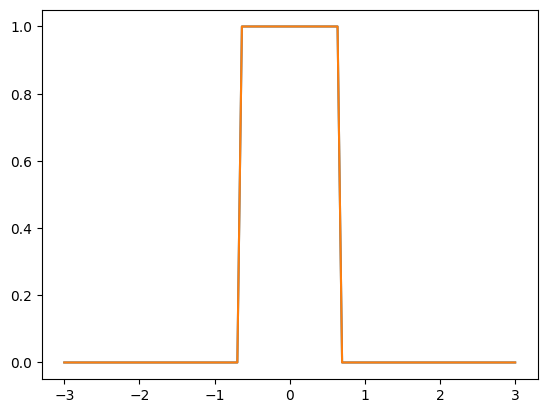

In [75]:
plt.plot(np.linspace(-3, 3, 100), [model.predict(np.array([[5e7, x, 0.1, 0.1, 0.1, x]])) for x in np.linspace(-3, 3, 100)] )
plt.plot(np.linspace(-3, 3, 100), [int(xgb_clf(np.array([[5e7, x, 0.1, 0.1, 0.1, x]]))[0] > 0) for x in np.linspace(-3, 3, 100)] )